<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula06c_reuters.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from tensorflow import keras
from tensorflow.keras.datasets import reuters
from sklearn.metrics import accuracy_score
import numpy as np
import matplotlib.pyplot as plt

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000, test_split=0.2)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
print(len(train_data))
print(len(test_data))

8982
2246


In [3]:
train_data[:2]

array([list([1, 2, 2, 8, 43, 10, 447, 5, 25, 207, 270, 5, 3095, 111, 16, 369, 186, 90, 67, 7, 89, 5, 19, 102, 6, 19, 124, 15, 90, 67, 84, 22, 482, 26, 7, 48, 4, 49, 8, 864, 39, 209, 154, 6, 151, 6, 83, 11, 15, 22, 155, 11, 15, 7, 48, 9, 4579, 1005, 504, 6, 258, 6, 272, 11, 15, 22, 134, 44, 11, 15, 16, 8, 197, 1245, 90, 67, 52, 29, 209, 30, 32, 132, 6, 109, 15, 17, 12]),
       list([1, 3267, 699, 3434, 2295, 56, 2, 7511, 9, 56, 3906, 1073, 81, 5, 1198, 57, 366, 737, 132, 20, 4093, 7, 2, 49, 2295, 2, 1037, 3267, 699, 3434, 8, 7, 10, 241, 16, 855, 129, 231, 783, 5, 4, 587, 2295, 2, 2, 775, 7, 48, 34, 191, 44, 35, 1795, 505, 17, 12])],
      dtype=object)

In [4]:
print(len(train_data[0]))
print(len(train_data[1]))

87
56


In [5]:
def decode_words(word_index, sentence):
  reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])
  decoded_sentence = ' '.join([reverse_word_index.get(i-3, '?') for i in sentence])
  return decoded_sentence

decode_words(reuters.get_word_index(), train_data[0])

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


'? ? ? said as a result of its december acquisition of space co it expects earnings per share in 1987 of 1 15 to 1 30 dlrs per share up from 70 cts in 1986 the company said pretax net should rise to nine to 10 mln dlrs from six mln dlrs in 1986 and rental operation revenues to 19 to 22 mln dlrs from 12 5 mln dlrs it said cash flow per share this year should be 2 50 to three dlrs reuter 3'

In [6]:
decode_words(reuters.get_word_index(), train_data[1])

'? generale de banque sa lt ? br and lt heller overseas corp of chicago have each taken 50 pct stakes in ? company sa ? factors generale de banque said in a statement it gave no financial details of the transaction sa ? ? turnover in 1986 was 17 5 billion belgian francs reuter 3'

In [8]:
len(set(train_labels))

46

In [9]:
def vectorize_sequence(sequence, dimension=10000):
  results = np.zeros((len(sequence), dimension))
  for i, sequence in enumerate(sequence):
    results[i, sequence] = 1
  return results

X_train = vectorize_sequence(train_data)
X_test = vectorize_sequence(test_data)
print(X_train.shape)
print(X_test.shape)
print(X_train[:3, :48])

(8982, 10000)
(2246, 10000)
[[0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0.
  0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1.]]


In [10]:
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=10000)
X_train = tokenizer.sequences_to_matrix(train_data)
X_test = tokenizer.sequences_to_matrix(test_data)
print(X_train.shape)
print(X_test.shape)
print(X_train[:3, :48])

(8982, 10000)
(2246, 10000)
[[0. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 0. 1. 0. 0. 1. 0.
  0. 1. 1. 0. 0. 1. 1. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 1. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 1. 1. 1. 0. 1. 0. 0. 0. 1. 1. 0. 0. 1. 0. 0. 0.
  0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 1. 1. 0. 1. 1. 0. 1. 0. 1. 0. 1. 1. 1. 1. 1. 0. 1. 1. 1. 0. 0. 0. 0.
  0. 0. 1. 0. 0. 1. 0. 0. 1. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 1. 0. 1. 1.]]


In [11]:
print(train_labels[:10])

[ 3  4  3  4  4  4  4  3  3 16]


In [12]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)
print(y_train.shape)

(8982, 46)


In [13]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
  layers.Dense(64, activation='relu'),
  layers.Dense(64, activation='relu'),
  layers.Dense(46, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [14]:
n_val = 1000
X_val = X_train[:n_val]
partial_X_train = X_train[n_val:]
y_val = y_train[:n_val]
partial_y_train = y_train[n_val:]

In [15]:
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 71ms/step - accuracy: 0.5122 - loss: 2.7064 - val_accuracy: 0.6300 - val_loss: 1.7751
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6863 - loss: 1.4893 - val_accuracy: 0.6960 - val_loss: 1.3315
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.7504 - loss: 1.1404 - val_accuracy: 0.7410 - val_loss: 1.1591
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8004 - loss: 0.9270 - val_accuracy: 0.7670 - val_loss: 1.0473
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.8311 - loss: 0.7702 - val_accuracy: 0.7910 - val_loss: 0.9668
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.8613 - loss: 0.6413 - val_accuracy: 0.7960 - val_loss: 0.9311
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.8834 - loss: 0.5380 - val_accuracy: 0.8070 - val_loss: 0.8983
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - accuracy: 0.9005 - loss: 0.4571 - val_accuracy: 0.8200 - v

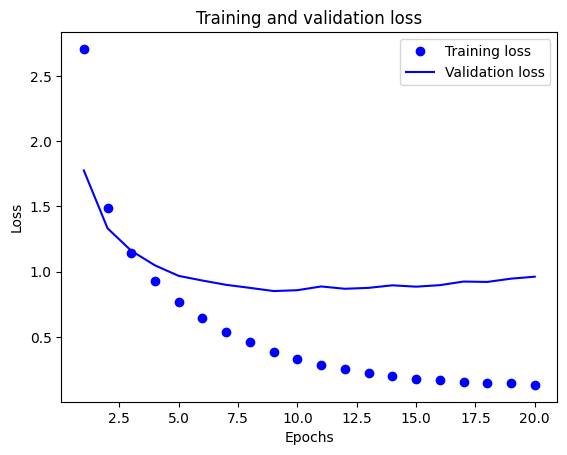

In [16]:
history_dict = history.history
loss_values = history_dict['loss']
val_loss_values = history_dict['val_loss']
epochs = range(1, len(loss_values)+1)
plt.plot(epochs, loss_values, 'bo', label='Training loss')
plt.plot(epochs, val_loss_values, 'b', label='Validation loss')
plt.title("Training and validation loss")
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

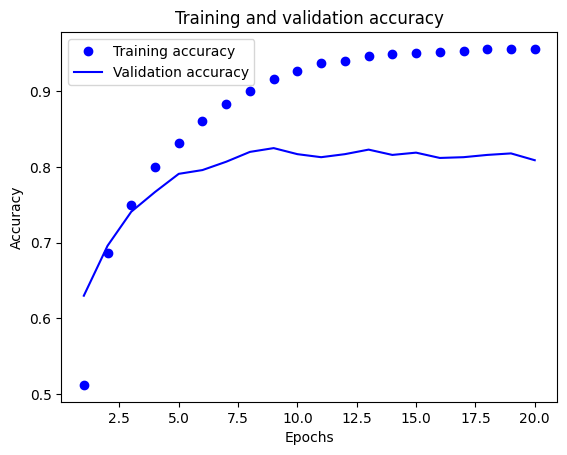

In [17]:
history_dict = history.history
acc_values = history_dict['accuracy']
val_acc_values = history_dict['val_accuracy']
epochs = range(1, len(loss_values)+1)
plt.plot(epochs, acc_values, 'bo', label='Training accuracy')
plt.plot(epochs, val_acc_values, 'b', label='Validation accuracy')
plt.title("Training and validation accuracy")
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [18]:
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=10,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9570 - loss: 0.1296 - val_accuracy: 0.8020 - val_loss: 0.9502
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9590 - loss: 0.1201 - val_accuracy: 0.8190 - val_loss: 0.9633
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - accuracy: 0.9575 - loss: 0.1201 - val_accuracy: 0.8060 - val_loss: 1.0352
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - accuracy: 0.9565 - loss: 0.1223 - val_accuracy: 0.8160 - val_loss: 0.9788
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9580 - loss: 0.1137 - val_accuracy: 0.8140 - val_loss: 0.9684
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9563 - loss: 0.1101 - val_accuracy: 0.8160 - val_loss: 1.0000
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.9572 - loss: 0.1071 - val_accuracy: 0.8020 - val_loss: 1.0298
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.9579 - loss: 0.1111 - val_accuracy: 0.8020 - v

In [19]:
y_pred = model.predict(X_test)
print(y_pred.shape)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
(2246, 46)


In [21]:
y_pred[:2]

array([[7.42298711e-09, 1.39893217e-08, 6.72879460e-11, 9.99916971e-01,
        7.17082439e-05, 1.82304005e-10, 1.16414468e-10, 6.53505161e-09,
        1.69355428e-06, 1.12842145e-08, 2.82674950e-09, 1.91483906e-07,
        7.05709553e-08, 2.15323382e-07, 2.62278288e-08, 1.84971736e-08,
        2.34069034e-07, 6.07200956e-10, 4.42722969e-09, 1.34051572e-06,
        5.89637921e-06, 2.23111371e-07, 2.06353135e-09, 2.86318147e-09,
        7.88853011e-11, 8.13570278e-09, 9.48844735e-12, 6.43283915e-09,
        4.06379902e-10, 6.41528743e-07, 1.04610249e-08, 8.67134350e-11,
        8.36190708e-08, 3.73553584e-11, 1.07455662e-07, 2.90293733e-10,
        1.54511142e-07, 1.75176407e-09, 1.31012268e-09, 2.94301515e-07,
        1.17685903e-10, 1.91669987e-08, 1.50634588e-10, 3.96080502e-10,
        4.62873406e-10, 1.91549193e-10],
       [1.85007666e-04, 3.94820333e-01, 4.26186671e-06, 1.64669856e-07,
        4.42825072e-03, 5.97342500e-04, 6.74221810e-05, 3.45580011e-05,
        2.92381202e-07,

In [22]:
for i in range(5):
  print(y_pred[i].argmax(), y_test[i].argmax())

3 3
10 10
1 1
16 4
13 4


In [23]:
results = model.evaluate(X_test, y_test)
print(results)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7872 - loss: 1.1649
[1.1649014949798584, 0.7871772050857544]


In [24]:
results = model.evaluate(partial_X_train, partial_y_train)
print(results)

250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9677 - loss: 0.0853
[0.08531609922647476, 0.9676772952079773]


In [25]:
results = model.evaluate(X_val, y_val)
print(results)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8070 - loss: 1.0798
[1.079763412475586, 0.8069999814033508]


In [26]:
model = keras.Sequential([
  layers.Dense(64, activation='relu'),
  layers.Dense(46, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 68ms/step - accuracy: 0.5336 - loss: 2.7659 - val_accuracy: 0.6320 - val_loss: 1.9696
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 50ms/step - accuracy: 0.6838 - loss: 1.6350 - val_accuracy: 0.6980 - val_loss: 1.4504
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.7518 - loss: 1.2159 - val_accuracy: 0.7480 - val_loss: 1.2078
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - accuracy: 0.7984 - loss: 0.9716 - val_accuracy: 0.7690 - val_loss: 1.0780
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 59ms/step - accuracy: 0.8336 - loss: 0.8074 - val_accuracy: 0.7930 - val_loss: 0.9902
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - accuracy: 0.8616 - loss: 0.6834 - val_accuracy: 0.8110 - val_loss: 0.9302
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 74ms/step - accuracy: 0.8837 - loss: 0.5828 - val_accuracy: 0.8220 - val_loss: 0.8795
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - accuracy: 0.8986 - loss: 0.5026 - val_accuracy: 0.8150 - v

In [27]:
model = keras.Sequential([
  layers.Dense(32, activation='relu'),
  layers.Dense(46, activation='softmax')
])
model.compile(optimizer='rmsprop',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
history = model.fit(partial_X_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(X_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 78ms/step - accuracy: 0.4886 - loss: 3.0668 - val_accuracy: 0.5920 - val_loss: 2.4456
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - accuracy: 0.6374 - loss: 2.0816 - val_accuracy: 0.6570 - val_loss: 1.8346
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step - accuracy: 0.6952 - loss: 1.5776 - val_accuracy: 0.6870 - val_loss: 1.5015
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.7410 - loss: 1.2824 - val_accuracy: 0.7210 - val_loss: 1.3084
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.7756 - loss: 1.0882 - val_accuracy: 0.7520 - val_loss: 1.1857
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8003 - loss: 0.9494 - val_accuracy: 0.7610 - val_loss: 1.1081
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.8236 - loss: 0.8401 - val_accuracy: 0.7770 - val_loss: 1.0433
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accuracy: 0.8444 - loss: 0.7512 - val_accuracy: 0.7910 - v

# PyTorch

In [29]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from sklearn.metrics import accuracy_score

model = nn.Sequential(
  nn.Linear(10000, 32),
  nn.ReLU(),
  nn.Linear(32, 46),
  nn.Softmax(dim=1)
)
criterion = nn.CrossEntropyLoss()
optimizer = optim.RMSprop(model.parameters())

partial_X_train = torch.tensor(partial_X_train, dtype=torch.float32)
partial_y_train = torch.tensor(partial_y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

num_epochs = 100
batch_size = 512

for epoch in range(num_epochs):
  for i in range(0, len(partial_X_train), batch_size):
    X_batch = partial_X_train[i:i+batch_size]
    y_batch = partial_y_train[i:i+batch_size]
    optimizer.zero_grad()
    outputs = model(X_batch)
    loss = criterion(outputs, y_batch)
    loss.backward()
    optimizer.step()
  val_loss = criterion(model(X_val), y_val)
  print(f"Epoch {epoch+1}/{num_epochs}, Training Loss: {loss.item():.4f}, Validation Loss: {val_loss.item():.4f}")


/tmp/ipykernel_1132/1560326508.py:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  partial_X_train = torch.tensor(partial_X_train, dtype=torch.float32)
/tmp/ipykernel_1132/1560326508.py:17: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  partial_y_train = torch.tensor(partial_y_train, dtype=torch.float32)
/tmp/ipykernel_1132/1560326508.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val, dtype=torch.float32)
/tmp/ipykernel_1132/1560326508.py:19: UserWarning: To copy construct from a tensor, it is recommended to 

Epoch 1/100, Training Loss: 3.1713, Validation Loss: 3.1724
Epoch 2/100, Training Loss: 3.1272, Validation Loss: 3.1602
Epoch 3/100, Training Loss: 3.1121, Validation Loss: 3.1586
Epoch 4/100, Training Loss: 3.0897, Validation Loss: 3.1398
Epoch 5/100, Training Loss: 3.0862, Validation Loss: 3.1311
Epoch 6/100, Training Loss: 3.0857, Validation Loss: 3.1520
Epoch 7/100, Training Loss: 3.0825, Validation Loss: 3.1343
Epoch 8/100, Training Loss: 3.0790, Validation Loss: 3.1342
Epoch 9/100, Training Loss: 3.0788, Validation Loss: 3.1344
Epoch 10/100, Training Loss: 3.0732, Validation Loss: 3.1361
Epoch 11/100, Training Loss: 3.0689, Validation Loss: 3.1327
Epoch 12/100, Training Loss: 3.0691, Validation Loss: 3.1356
Epoch 13/100, Training Loss: 3.0632, Validation Loss: 3.1316
Epoch 14/100, Training Loss: 3.0504, Validation Loss: 3.1131
Epoch 15/100, Training Loss: 3.0495, Validation Loss: 3.1101
Epoch 16/100, Training Loss: 3.0494, Validation Loss: 3.1091
Epoch 17/100, Training Loss: 3.04

In [34]:
with torch.no_grad():
  outputs = model(X_test)
  _, predicted = torch.max(outputs, 1)
  acc = accuracy_score(test_labels, predicted.numpy())
  print(f"Test Accuracy: {acc:.4f}")

Test Accuracy: 0.7827
